# MNIST Binary Classification – K-Nearest Neighbors

## Complete Pipeline: Data Loading -> Preprocessing -> Feature Extraction -> Training -> Evaluation

## 1. Environment Setup and Imports

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ml_utils import train_test_split, StandardScaler
from ml_utils import classification_report, confusion_matrix
from sklearn.decomposition import PCA
from skimage.feature import hog
from tqdm import tqdm

np.random.seed(42)
print("Libraries imported successfully")

Libraries imported successfully


## 2. Configuration

In [46]:
DIGIT_A = 0
DIGIT_B = 1

TRAIN_SIZE = 0.70
VAL_SIZE   = 0.15
TEST_SIZE  = 0.15

PCA_VARIANCE = 0.95   # keep 95 % variance

# KNN hyper-parameters
K_NEIGHBORS = 5

print("Configuration:")
print(f"  Binary Classification: Digit {DIGIT_A} vs Digit {DIGIT_B}")
print(f"  Train/Val/Test Split : {TRAIN_SIZE:.0%}/{VAL_SIZE:.0%}/{TEST_SIZE:.0%}")
print(f"  PCA Variance Retained: {PCA_VARIANCE:.0%}")
print(f"  K Neighbors          : {K_NEIGHBORS}")

Configuration:
  Binary Classification: Digit 0 vs Digit 1
  Train/Val/Test Split : 70%/15%/15%
  PCA Variance Retained: 95%
  K Neighbors          : 5


## 3. Load and Inspect MNIST Dataset

In [47]:
print("=" * 70)
print("LOADING DATA")
print("=" * 70)

X_train_raw = np.load('../mnist.npz/x_train.npy')
y_train_raw = np.load('../mnist.npz/y_train.npy')
X_test_raw  = np.load('../mnist.npz/x_test.npy')
y_test_raw  = np.load('../mnist.npz/y_test.npy')

print(f"Training data shape: X={X_train_raw.shape}, y={y_train_raw.shape}")
print(f"Test data shape:     X={X_test_raw.shape}, y={y_test_raw.shape}")
print("\nData loaded successfully")

LOADING DATA
Training data shape: X=(60000, 28, 28), y=(60000,)
Test data shape:     X=(10000, 28, 28), y=(10000,)

Data loaded successfully


### Visualise Sample Images

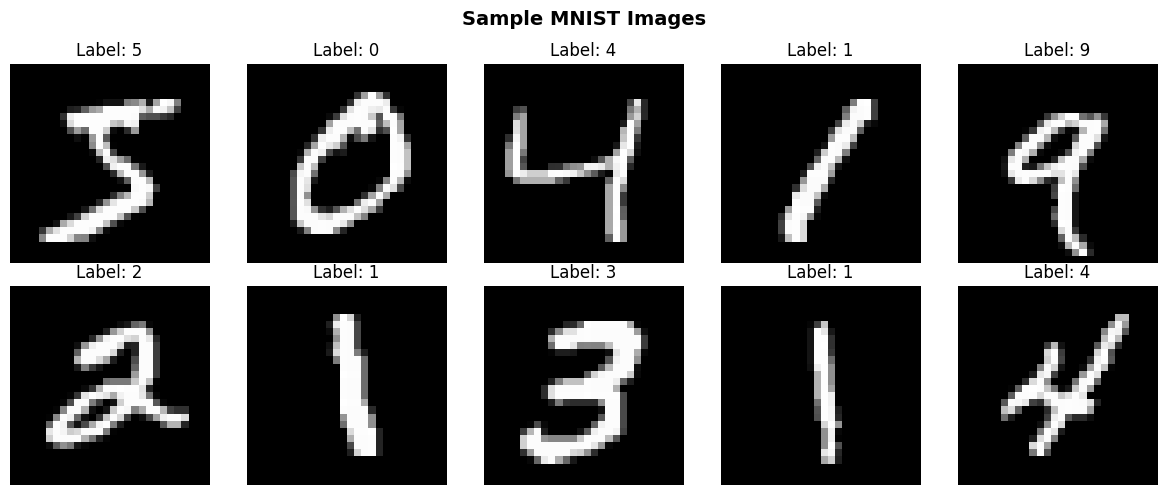

In [48]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()
for i in range(10):
    axes[i].imshow(X_train_raw[i], cmap='gray')
    axes[i].set_title(f'Label: {y_train_raw[i]}')
    axes[i].axis('off')
plt.suptitle('Sample MNIST Images', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

### Class Distribution (full training set)

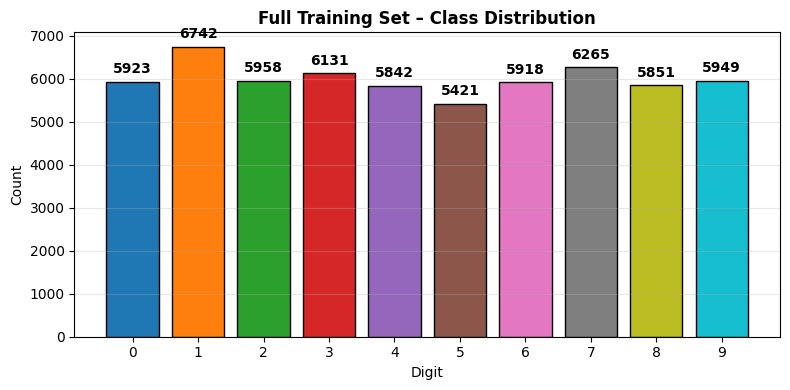

In [ ]:
unique, counts = np.unique(y_train_raw, return_counts=True)
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(unique, counts, color=plt.cm.tab10(unique/10), edgecolor='black')
for b, c in zip(bars, counts):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+200,
            str(c), ha='center', fontweight='bold')
ax.set_xlabel('Digit'); ax.set_ylabel('Count')
ax.set_title('Full Training Set - Class Distribution', fontweight='bold')
ax.set_xticks(unique); ax.grid(axis='y', alpha=.3)
plt.tight_layout(); plt.show()

## 4. Preprocessing

### Filter Binary Classes

In [50]:
print("=" * 70)
print(f"FILTERING BINARY CLASSES: {DIGIT_A} vs {DIGIT_B}")
print("=" * 70)

train_mask = (y_train_raw == DIGIT_A) | (y_train_raw == DIGIT_B)
X_filtered = X_train_raw[train_mask]
y_filtered = (y_train_raw[train_mask] == DIGIT_B).astype(int)

print(f"Filtered dataset size: {len(y_filtered)}")
print(f"Class 0 ({DIGIT_A}): {np.sum(y_filtered==0)}")
print(f"Class 1 ({DIGIT_B}): {np.sum(y_filtered==1)}")

FILTERING BINARY CLASSES: 0 vs 1
Filtered dataset size: 12665
Class 0 (0): 5923
Class 1 (1): 6742


### Balance Training Set

In [51]:
class0_idx = np.where(y_filtered == 0)[0]
class1_idx = np.where(y_filtered == 1)[0]
min_count  = min(len(class0_idx), len(class1_idx))

np.random.shuffle(class0_idx)
np.random.shuffle(class1_idx)
balanced_idx = np.concatenate([class0_idx[:min_count], class1_idx[:min_count]])
np.random.shuffle(balanced_idx)

X_balanced = X_filtered[balanced_idx]
y_balanced = y_filtered[balanced_idx]

print(f"Balanced dataset size: {len(y_balanced)}")
print(f"  Class 0 ({DIGIT_A}): {np.sum(y_balanced==0)}")
print(f"  Class 1 ({DIGIT_B}): {np.sum(y_balanced==1)}")
print("\nTraining set balanced")

Balanced dataset size: 11846
  Class 0 (0): 5923
  Class 1 (1): 5923

Training set balanced


### Visualise Binary Classes and Balance

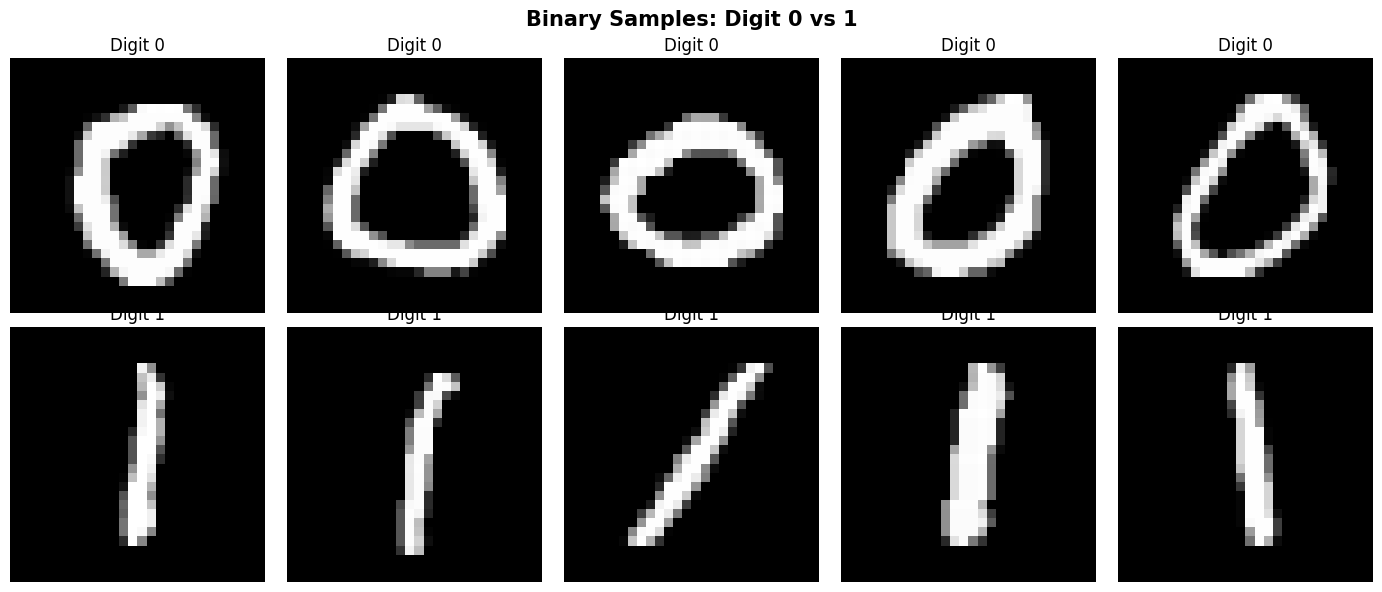

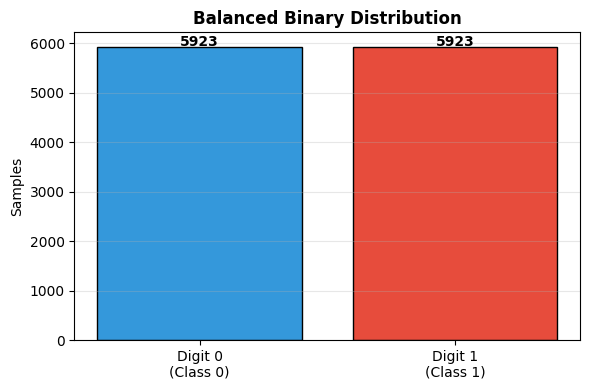

In [52]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
c0 = np.where(y_balanced==0)[0]; c1 = np.where(y_balanced==1)[0]
for i in range(5):
    axes[0,i].imshow(X_balanced[c0[i]], cmap='gray')
    axes[0,i].set_title(f'Digit {DIGIT_A}'); axes[0,i].axis('off')
    axes[1,i].imshow(X_balanced[c1[i]], cmap='gray')
    axes[1,i].set_title(f'Digit {DIGIT_B}'); axes[1,i].axis('off')
plt.suptitle(f'Binary Samples: Digit {DIGIT_A} vs {DIGIT_B}',
             fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
cnts = [np.sum(y_balanced==0), np.sum(y_balanced==1)]
ax.bar([f'Digit {DIGIT_A}\n(Class 0)', f'Digit {DIGIT_B}\n(Class 1)'],
       cnts, color=['#3498db','#e74c3c'], edgecolor='black')
for b, c in zip(ax.patches, cnts):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+30,
            str(c), ha='center', fontweight='bold')
ax.set_ylabel('Samples'); ax.set_title('Balanced Binary Distribution', fontweight='bold')
ax.grid(axis='y', alpha=.3); plt.tight_layout(); plt.show()

### Normalize Pixel Values

In [53]:
X_norm = X_balanced / 255.0
print("Pixel values normalised to [0, 1]")

Pixel values normalised to [0, 1]


### Split Data

In [54]:
print("=" * 70)
print("SPLITTING DATA")
print("=" * 70)

X_temp, X_test, y_temp, y_test = train_test_split(
    X_norm, y_balanced,
    test_size=TEST_SIZE/(TRAIN_SIZE+VAL_SIZE+TEST_SIZE),
    random_state=42, stratify=y_balanced)

val_adj = VAL_SIZE / (TRAIN_SIZE + VAL_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=val_adj, random_state=42, stratify=y_temp)

print(f"Training set:   {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set:       {X_test.shape[0]} samples")
print("\nData split completed")

SPLITTING DATA
Training set:   8292 samples
Validation set: 1778 samples
Test set:       1776 samples

Data split completed


### Class Distribution Across Splits

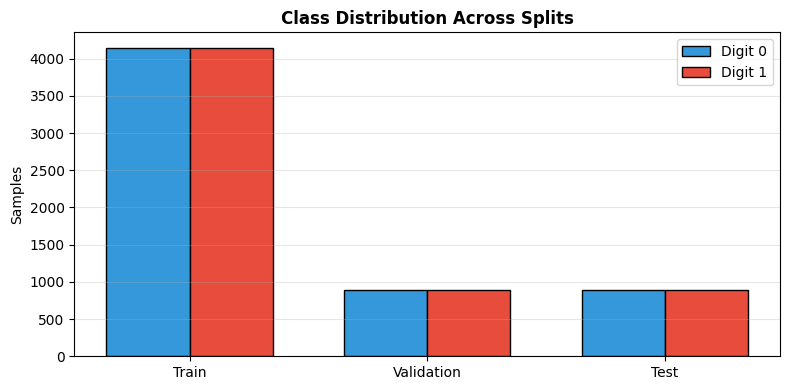

In [55]:
fig, ax = plt.subplots(figsize=(8, 4))
splits = ['Train', 'Validation', 'Test']
c0s = [np.sum(y_train==0), np.sum(y_val==0), np.sum(y_test==0)]
c1s = [np.sum(y_train==1), np.sum(y_val==1), np.sum(y_test==1)]
x = np.arange(len(splits)); w = 0.35
ax.bar(x - w/2, c0s, w, label=f'Digit {DIGIT_A}', color='#3498db', edgecolor='black')
ax.bar(x + w/2, c1s, w, label=f'Digit {DIGIT_B}', color='#e74c3c', edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(splits)
ax.set_ylabel('Samples'); ax.set_title('Class Distribution Across Splits', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=.3)
plt.tight_layout(); plt.show()

## 5. Feature Extraction

We compare three feature extraction methods:
- **Flatten** - reshape each 28x28 image into a 784-dimensional vector
- **HOG** - Histogram of Oriented Gradients (captures edge/shape information)
- **PCA** - Principal Component Analysis (reduces dimensionality while preserving 95% variance)

### 5.1 Flatten

In [ ]:
print("=" * 70)
print("FEATURE EXTRACTION - FLATTEN")
print("=" * 70)

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat   = X_val.reshape(X_val.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)

scaler_flat = StandardScaler()
X_train_flat_sc = scaler_flat.fit_transform(X_train_flat)
X_val_flat_sc   = scaler_flat.transform(X_val_flat)
X_test_flat_sc  = scaler_flat.transform(X_test_flat)

print(f"Flatten feature dim: {X_train_flat_sc.shape[1]}")
print("Flatten features ready")

FEATURE EXTRACTION – FLATTEN
Flatten feature dim: 784
Flatten features ready


#### Visualise Flattening

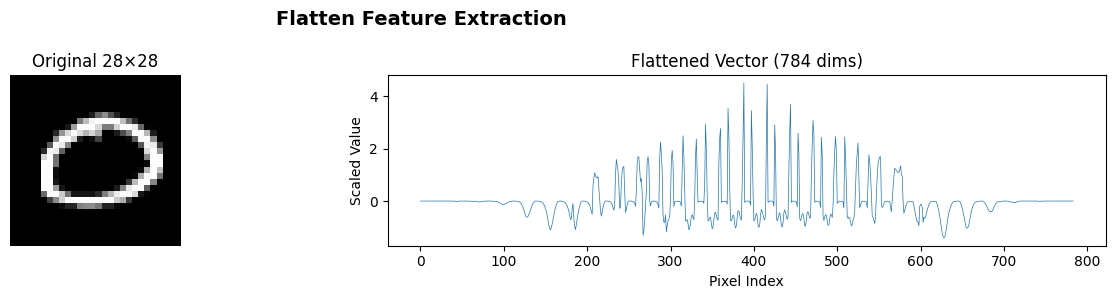

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3))
axes[0].imshow(X_train[0], cmap='gray'); axes[0].set_title('Original 28x28'); axes[0].axis('off')
axes[1].plot(X_train_flat_sc[0], linewidth=0.5)
axes[1].set_title(f'Flattened Vector ({X_train_flat_sc.shape[1]} dims)')
axes[1].set_xlabel('Pixel Index'); axes[1].set_ylabel('Scaled Value')
plt.suptitle('Flatten Feature Extraction', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

### 5.2 HOG (Histogram of Oriented Gradients)

In [ ]:
print("=" * 70)
print("FEATURE EXTRACTION - HOG")
print("=" * 70)

def extract_hog(images):
    feats = []
    for img in images:
        f = hog(img, orientations=9, pixels_per_cell=(4,4),
                cells_per_block=(2,2), block_norm='L2-Hys')
        feats.append(f)
    return np.array(feats)

X_train_hog = extract_hog(X_train)
X_val_hog   = extract_hog(X_val)
X_test_hog  = extract_hog(X_test)

scaler_hog = StandardScaler()
X_train_hog_sc = scaler_hog.fit_transform(X_train_hog)
X_val_hog_sc   = scaler_hog.transform(X_val_hog)
X_test_hog_sc  = scaler_hog.transform(X_test_hog)

print(f"HOG feature dim: {X_train_hog_sc.shape[1]}")
print("HOG features ready")

FEATURE EXTRACTION – HOG
HOG feature dim: 1296
HOG features ready


#### Visualise HOG

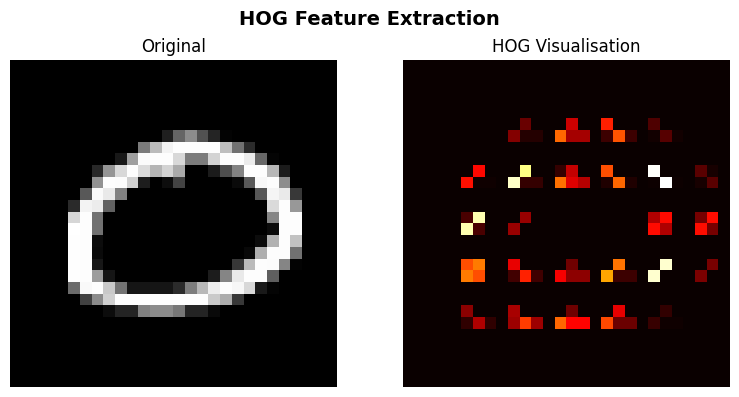

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(X_train[0], cmap='gray'); axes[0].set_title('Original'); axes[0].axis('off')
_, hog_img = hog(X_train[0], orientations=9, pixels_per_cell=(4,4),
                 cells_per_block=(2,2), block_norm='L2-Hys', visualize=True)
axes[1].imshow(hog_img, cmap='hot'); axes[1].set_title('HOG Visualisation'); axes[1].axis('off')
plt.suptitle('HOG Feature Extraction', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

### 5.3 PCA (Principal Component Analysis)

In [ ]:
print("=" * 70)
print(f"FEATURE EXTRACTION - PCA (variance={PCA_VARIANCE})")
print("=" * 70)

pca = PCA(n_components=PCA_VARIANCE, svd_solver='full')
X_train_pca = pca.fit_transform(X_train_flat_sc)
X_val_pca   = pca.transform(X_val_flat_sc)
X_test_pca  = pca.transform(X_test_flat_sc)

cum_var = np.cumsum(pca.explained_variance_ratio_)
print(f"Original features : {X_train_flat_sc.shape[1]}")
print(f"PCA components    : {X_train_pca.shape[1]}")
print(f"Explained variance: {cum_var[-1]:.4f}")
print("PCA features ready")

FEATURE EXTRACTION – PCA (variance=0.95)
Original features : 784
PCA components    : 195
Explained variance: 0.9501
PCA features ready


#### Visualise PCA

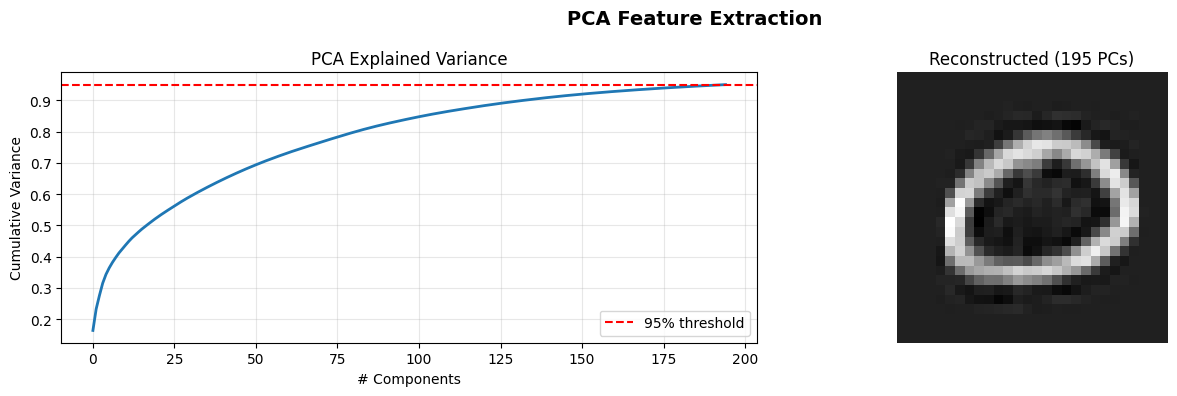

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(cum_var, linewidth=2)
axes[0].axhline(PCA_VARIANCE, ls='--', color='red', label=f'{PCA_VARIANCE:.0%} threshold')
axes[0].set_xlabel('# Components'); axes[0].set_ylabel('Cumulative Variance')
axes[0].set_title('PCA Explained Variance'); axes[0].legend(); axes[0].grid(alpha=.3)

recon = pca.inverse_transform(X_train_pca[0:1])
recon = scaler_flat.inverse_transform(recon).reshape(28,28)
axes[1].imshow(recon, cmap='gray'); axes[1].set_title(f'Reconstructed ({X_train_pca.shape[1]} PCs)')
axes[1].axis('off')
plt.suptitle('PCA Feature Extraction', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 6. K-Nearest Neighbors Model

The KNN classifier uses **Euclidean distance** and **majority voting** among the K nearest training samples.

In [63]:
class KNearestNeighbors:
    def __init__(self, k=5):
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
        return self

    def _predict_single(self, x):
        dists = np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))
        k_idx = np.argsort(dists)[:self.k]
        k_labels = self.y_train[k_idx]
        counts = np.bincount(k_labels)
        return np.argmax(counts)

    def predict(self, X):
        preds = []
        for i in tqdm(range(len(X)), desc='Predicting'):
            preds.append(self._predict_single(X[i]))
        return np.array(preds)

## 7. Model Training & Evaluation

### Training on Flatten Features

TRAINING KNN – Flatten features


Predicting: 100%|██████████| 1776/1776 [02:08<00:00, 13.86it/s]


Training Accuracy:   0.9982 (99.82%)
Validation Accuracy: 0.9955 (99.55%)
Test Accuracy:       0.9989 (99.89%)

Classification Report:
                 precision     recall   f1-score    support

        Digit 0       1.00       1.00       1.00        888
        Digit 1       1.00       1.00       1.00        888

       accuracy                             1.00       1776
      macro avg       1.00       1.00       1.00       1776
   weighted avg       1.00       1.00       1.00       1776



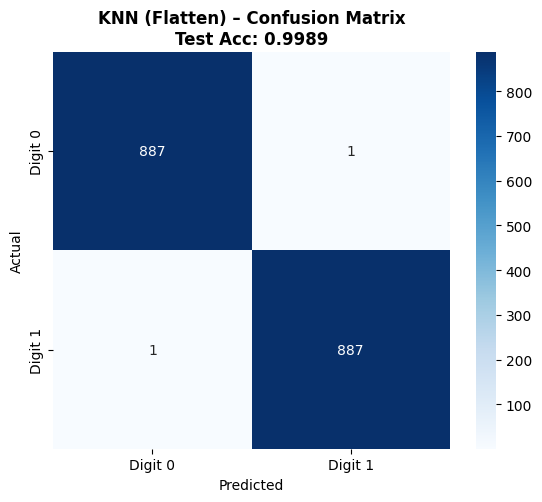

Misclassified: 2 / 1776


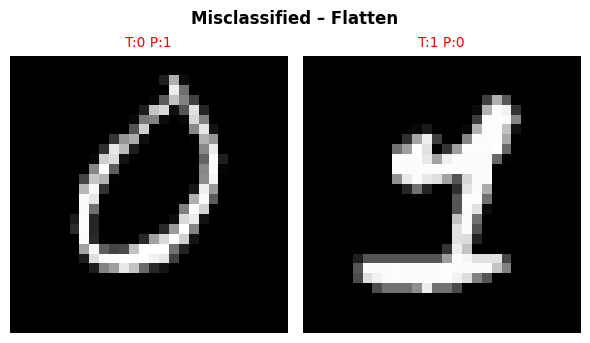

In [64]:
print("=" * 70)
print("TRAINING KNN - Flatten features")
print("=" * 70)

knn_flat_sc = KNearestNeighbors(k=K_NEIGHBORS)
knn_flat_sc.fit(X_train_flat_sc, y_train)

train_pred = knn_flat_sc.predict(X_train_flat_sc)
val_pred   = knn_flat_sc.predict(X_val_flat_sc)
test_pred  = knn_flat_sc.predict(X_test_flat_sc)

train_acc = np.mean(train_pred == y_train)
val_acc   = np.mean(val_pred == y_val)
test_acc_flat_sc  = np.mean(test_pred == y_test)

print(f"Training Accuracy:   {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"Validation Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")
print(f"Test Accuracy:       {test_acc_flat_sc:.4f} ({test_acc_flat_sc*100:.2f}%)")

# Detailed Metrics 
cm = confusion_matrix(y_test, test_pred)
print("\nClassification Report:")
print(classification_report(y_test, test_pred,
      target_names=[f'Digit {DIGIT_A}', f'Digit {DIGIT_B}']))

# Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Digit {DIGIT_A}', f'Digit {DIGIT_B}'],
            yticklabels=[f'Digit {DIGIT_A}', f'Digit {DIGIT_B}'],
            cbar=True, square=True)
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.title(f'KNN (Flatten) - Confusion Matrix\nTest Acc: {test_acc_flat_sc:.4f}',
          fontweight='bold')
plt.tight_layout(); plt.show()

# Misclassified Samples
wrong = np.where(test_pred != y_test)[0]
n_wrong = len(wrong)
print(f"Misclassified: {n_wrong} / {len(y_test)}")
n_show = min(n_wrong, 10)
if n_show > 0:
    cols = min(n_show, 5); rows = (n_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3.5*rows))
    axes = np.array(axes).reshape(rows, cols)
    for k in range(n_show):
        r, c = divmod(k, cols); idx = wrong[k]
        td = DIGIT_A if y_test[idx]==0 else DIGIT_B
        pd_ = DIGIT_A if test_pred[idx]==0 else DIGIT_B
        axes[r,c].imshow(X_test[idx], cmap='gray')
        axes[r,c].set_title(f'T:{td} P:{pd_}', color='red', fontsize=10)
        axes[r,c].axis('off')
    for k in range(n_show, rows*cols):
        r, c = divmod(k, cols); axes[r,c].axis('off')
    plt.suptitle(f'Misclassified - Flatten', fontweight='bold')
    plt.tight_layout(); plt.show()

### Training on HOG Features

TRAINING KNN - HOG features


Predicting: 100%|██████████| 1776/1776 [01:45<00:00, 16.87it/s]


Training Accuracy:   0.9959 (99.59%)
Validation Accuracy: 0.9927 (99.27%)
Test Accuracy:       0.9944 (99.44%)

Classification Report:
                 precision     recall   f1-score    support

        Digit 0       0.99       1.00       0.99        888
        Digit 1       1.00       0.99       0.99        888

       accuracy                             0.99       1776
      macro avg       0.99       0.99       0.99       1776
   weighted avg       0.99       0.99       0.99       1776



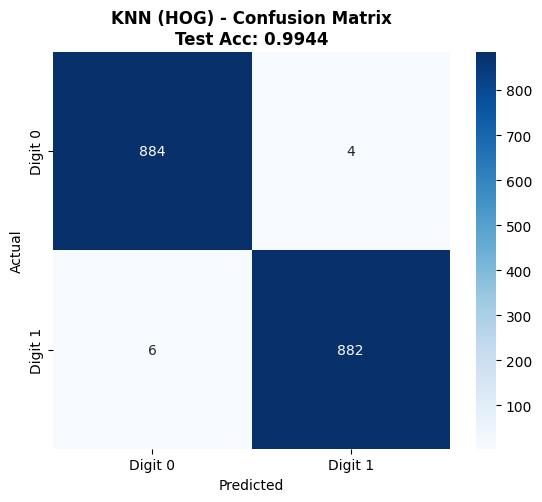

Misclassified: 10 / 1776


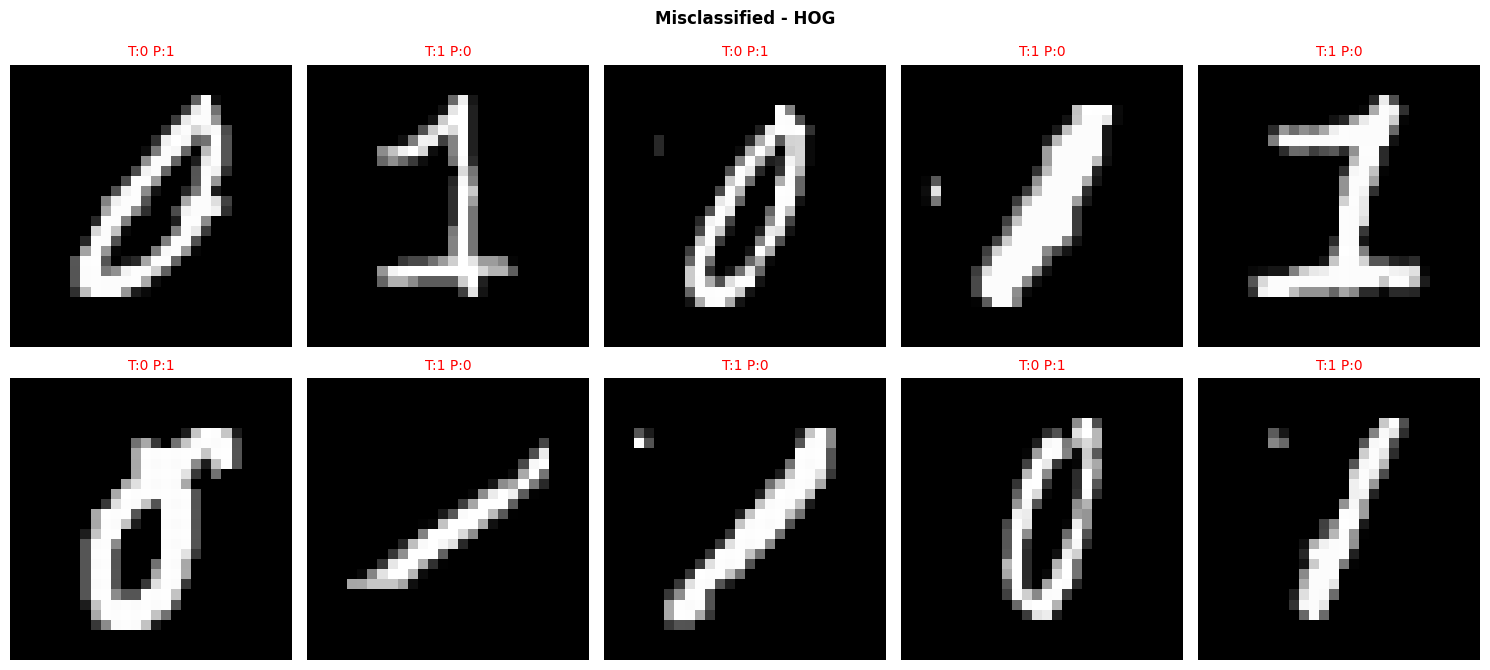

In [65]:
print("=" * 70)
print("TRAINING KNN - HOG features")
print("=" * 70)

knn_hog_sc = KNearestNeighbors(k=K_NEIGHBORS)
knn_hog_sc.fit(X_train_hog_sc, y_train)

train_pred = knn_hog_sc.predict(X_train_hog_sc)
val_pred   = knn_hog_sc.predict(X_val_hog_sc)
test_pred  = knn_hog_sc.predict(X_test_hog_sc)

train_acc = np.mean(train_pred == y_train)
val_acc   = np.mean(val_pred == y_val)
test_acc_hog_sc  = np.mean(test_pred == y_test)

print(f"Training Accuracy:   {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"Validation Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")
print(f"Test Accuracy:       {test_acc_hog_sc:.4f} ({test_acc_hog_sc*100:.2f}%)")

# Detailed Metrics 
cm = confusion_matrix(y_test, test_pred)
print("\nClassification Report:")
print(classification_report(y_test, test_pred,
      target_names=[f'Digit {DIGIT_A}', f'Digit {DIGIT_B}']))

# Confusion Matrix 
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Digit {DIGIT_A}', f'Digit {DIGIT_B}'],
            yticklabels=[f'Digit {DIGIT_A}', f'Digit {DIGIT_B}'],
            cbar=True, square=True)
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.title(f'KNN (HOG) - Confusion Matrix\nTest Acc: {test_acc_hog_sc:.4f}',
          fontweight='bold')
plt.tight_layout(); plt.show()

# Misclassified Samples 
wrong = np.where(test_pred != y_test)[0]
n_wrong = len(wrong)
print(f"Misclassified: {n_wrong} / {len(y_test)}")
n_show = min(n_wrong, 10)
if n_show > 0:
    cols = min(n_show, 5); rows = (n_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3.5*rows))
    axes = np.array(axes).reshape(rows, cols)
    for k in range(n_show):
        r, c = divmod(k, cols); idx = wrong[k]
        td = DIGIT_A if y_test[idx]==0 else DIGIT_B
        pd_ = DIGIT_A if test_pred[idx]==0 else DIGIT_B
        axes[r,c].imshow(X_test[idx], cmap='gray')
        axes[r,c].set_title(f'T:{td} P:{pd_}', color='red', fontsize=10)
        axes[r,c].axis('off')
    for k in range(n_show, rows*cols):
        r, c = divmod(k, cols); axes[r,c].axis('off')
    plt.suptitle(f'Misclassified - HOG', fontweight='bold')
    plt.tight_layout(); plt.show()

### Training on PCA Features

TRAINING KNN - PCA features


Predicting: 100%|██████████| 1776/1776 [00:24<00:00, 71.51it/s]


Training Accuracy:   0.9983 (99.83%)
Validation Accuracy: 0.9961 (99.61%)
Test Accuracy:       0.9983 (99.83%)

Classification Report:
                 precision     recall   f1-score    support

        Digit 0       1.00       1.00       1.00        888
        Digit 1       1.00       1.00       1.00        888

       accuracy                             1.00       1776
      macro avg       1.00       1.00       1.00       1776
   weighted avg       1.00       1.00       1.00       1776



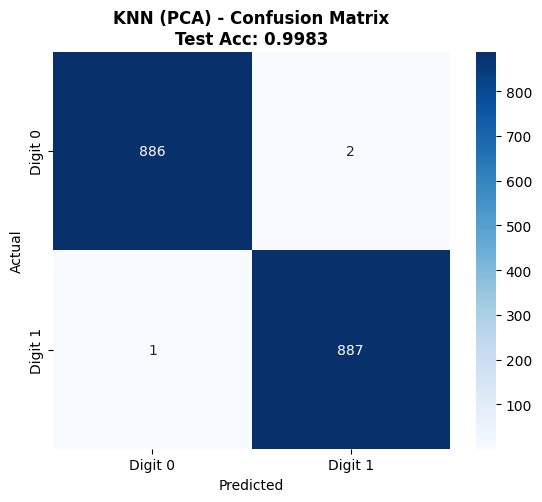

Misclassified: 3 / 1776


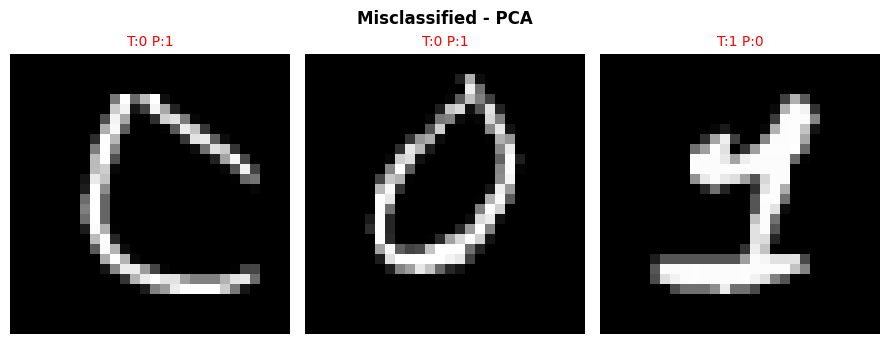

In [66]:
print("=" * 70)
print("TRAINING KNN - PCA features")
print("=" * 70)

knn_pca = KNearestNeighbors(k=K_NEIGHBORS)
knn_pca.fit(X_train_pca, y_train)

train_pred = knn_pca.predict(X_train_pca)
val_pred   = knn_pca.predict(X_val_pca)
test_pred  = knn_pca.predict(X_test_pca)

train_acc = np.mean(train_pred == y_train)
val_acc   = np.mean(val_pred == y_val)
test_acc_pca  = np.mean(test_pred == y_test)

print(f"Training Accuracy:   {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"Validation Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")
print(f"Test Accuracy:       {test_acc_pca:.4f} ({test_acc_pca*100:.2f}%)")

# Detailed Metrics 
cm = confusion_matrix(y_test, test_pred)
print("\nClassification Report:")
print(classification_report(y_test, test_pred,
      target_names=[f'Digit {DIGIT_A}', f'Digit {DIGIT_B}']))

# Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Digit {DIGIT_A}', f'Digit {DIGIT_B}'],
            yticklabels=[f'Digit {DIGIT_A}', f'Digit {DIGIT_B}'],
            cbar=True, square=True)
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.title(f'KNN (PCA) - Confusion Matrix\nTest Acc: {test_acc_pca:.4f}',
          fontweight='bold')
plt.tight_layout(); plt.show()

# Misclassified Samples
wrong = np.where(test_pred != y_test)[0]
n_wrong = len(wrong)
print(f"Misclassified: {n_wrong} / {len(y_test)}")
n_show = min(n_wrong, 10)
if n_show > 0:
    cols = min(n_show, 5); rows = (n_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3.5*rows))
    axes = np.array(axes).reshape(rows, cols)
    for k in range(n_show):
        r, c = divmod(k, cols); idx = wrong[k]
        td = DIGIT_A if y_test[idx]==0 else DIGIT_B
        pd_ = DIGIT_A if test_pred[idx]==0 else DIGIT_B
        axes[r,c].imshow(X_test[idx], cmap='gray')
        axes[r,c].set_title(f'T:{td} P:{pd_}', color='red', fontsize=10)
        axes[r,c].axis('off')
    for k in range(n_show, rows*cols):
        r, c = divmod(k, cols); axes[r,c].axis('off')
    plt.suptitle(f'Misclassified - PCA', fontweight='bold')
    plt.tight_layout(); plt.show()

## 8. Results Comparison

### Accuracy Comparison

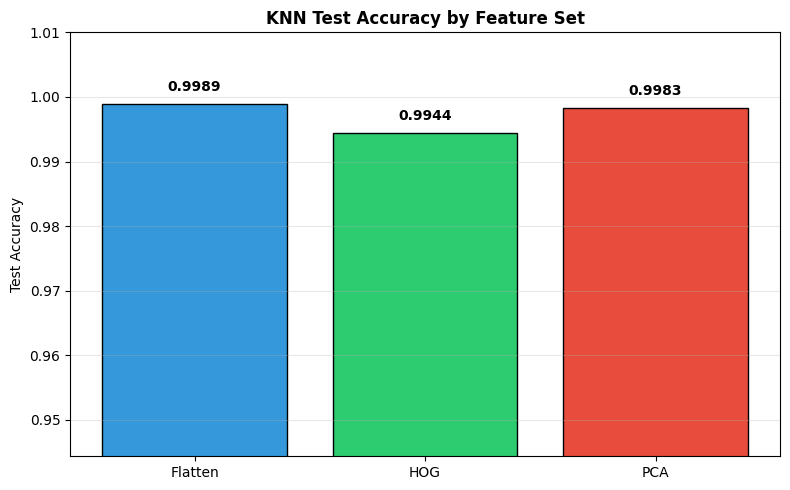

In [67]:
fig, ax = plt.subplots(figsize=(8, 5))
names = ['Flatten', 'HOG', 'PCA']
accs  = [test_acc_flat_sc, test_acc_hog_sc, test_acc_pca]
bars  = ax.bar(names, accs, color=['#3498db','#2ecc71','#e74c3c'], edgecolor='black')
for b, a in zip(bars, accs):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.002,
            f'{a:.4f}', ha='center', fontweight='bold')
ax.set_ylim(min(accs)-0.05, 1.01)
ax.set_ylabel('Test Accuracy'); ax.set_title('KNN Test Accuracy by Feature Set', fontweight='bold')
ax.grid(axis='y', alpha=.3); plt.tight_layout(); plt.show()

## 9. Summary

In [68]:
print("\n" + "=" * 70)
print("KNN - COMPLETE PIPELINE SUMMARY")
print("=" * 70)
print(f"\nConfiguration:")
print(f"  Digits: {DIGIT_A} vs {DIGIT_B}")
print(f"  K Neighbors : {K_NEIGHBORS}")
print(f"\nDataset:")
print(f"  Training:   {len(y_train)} samples")
print(f"  Validation: {len(y_val)} samples")
print(f"  Test:       {len(y_test)} samples")
print(f"\nTest Results:")
print(f"  Flatten : {test_acc_flat_sc:.4f} ({test_acc_flat_sc*100:.2f}%)")
print(f"  HOG     : {test_acc_hog_sc:.4f} ({test_acc_hog_sc*100:.2f}%)")
print(f"  PCA     : {test_acc_pca:.4f} ({test_acc_pca*100:.2f}%)")
print("=" * 70)
print("\nPipeline completed successfully!")


KNN - COMPLETE PIPELINE SUMMARY

Configuration:
  Digits: 0 vs 1
  K Neighbors : 5

Dataset:
  Training:   8292 samples
  Validation: 1778 samples
  Test:       1776 samples

Test Results:
  Flatten : 0.9989 (99.89%)
  HOG     : 0.9944 (99.44%)
  PCA     : 0.9983 (99.83%)

Pipeline completed successfully!
